In [1]:

# Step 1: Install necessary libraries
!pip install pennylane chembl-webresource-client rdkit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.2/34.2 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.0/930.0 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 6.2 MB/s eta 0:00:00


In [2]:
#Step 2: Import Libraries
import pennylane as qml
from pennylane import numpy as np
from chembl_webresource_client.new_client import new_client
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
import matplotlib.pyplot as plt


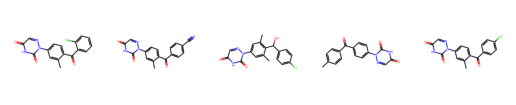

In [3]:
#Step 3: Fetch and Prepare the Dataset
# Fetch molecular data with no Rule-of-5 violations
molecule = new_client.molecule
molecule_list = molecule.filter(
    molecule_properties__num_ro5_violations=0
).only('molecule_chembl_id', 'molecule_structures')[:5]

# Extract SMILES strings and convert to RDKit molecular objects
smiles_list = [mol['molecule_structures']['canonical_smiles'] for mol in molecule_list]
rdkit_molecules = [Chem.MolFromSmiles(smile) for smile in smiles_list]

# Visualize molecules
for i, mol in enumerate(rdkit_molecules):
    img = Draw.MolToImage(mol, size=(200, 200))
    plt.subplot(1, len(rdkit_molecules), i + 1)
    plt.imshow(img)
    plt.axis('off')
plt.show()


In [4]:
#Step 4: Generate Molecular Hamiltonian
def generate_hamiltonian(molecule):
    # Add hydrogens and optimize geometry
    molecule = Chem.AddHs(molecule)
    AllChem.EmbedMolecule(molecule)
    AllChem.UFFOptimizeMolecule(molecule)

    # Define a dummy Hamiltonian (2-qubit example)
    num_qubits = 2
    hamiltonian = np.array([[1.0, 0.0, 0.0, 0.0],
                            [0.0, -1.0, 0.0, 0.0],
                            [0.0, 0.0, 1.0, 0.0],
                            [0.0, 0.0, 0.0, -1.0]])
    return num_qubits, hamiltonian

# Generate Hamiltonian for the first molecule
num_qubits, hamiltonian = generate_hamiltonian(rdkit_molecules[0])
print(f"Number of qubits: {num_qubits}")
print(f"Hamiltonian:\n{hamiltonian}")


Number of qubits: 2
Hamiltonian:
[[ 1.  0.  0.  0.]
 [ 0. -1.  0.  0.]
 [ 0.  0.  1.  0.]
 [ 0.  0.  0. -1.]]


In [5]:
#Step 5: Run Quantum Simulation
def run_quantum_simulation(num_qubits, hamiltonian):
    # Initialize quantum device
    dev = qml.device('default.qubit', wires=num_qubits)

    # Define quantum circuit
    @qml.qnode(dev)
    def circuit():
        qml.Hadamard(wires=0)
        qml.CNOT(wires=[0, 1])
        qml.QubitUnitary(hamiltonian, wires=range(num_qubits))
        return qml.probs(wires=range(num_qubits))

    # Run simulation
    probabilities = circuit()
    return probabilities

# Run simulation and display results
probabilities = run_quantum_simulation(num_qubits, hamiltonian)
print("Quantum state probabilities:", probabilities)


Quantum state probabilities: [0.5 0.  0.  0.5]


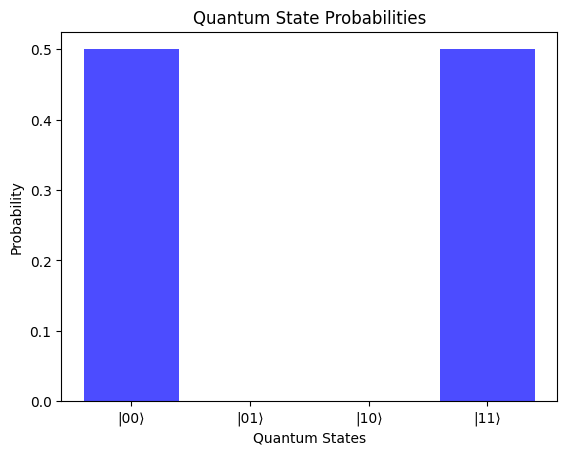

In [6]:
def plot_probabilities(probabilities):
    plt.bar(range(len(probabilities)), probabilities, color='blue', alpha=0.7)
    plt.xlabel("Quantum States")
    plt.ylabel("Probability")
    plt.title("Quantum State Probabilities")
    plt.xticks(range(len(probabilities)), [f"|{i:02b}⟩" for i in range(len(probabilities))])
    plt.show()

# Plot the probabilities
plot_probabilities(probabilities)



Analyzing molecule 1:
Probabilities for molecule 1: [0.5 0.  0.  0.5]


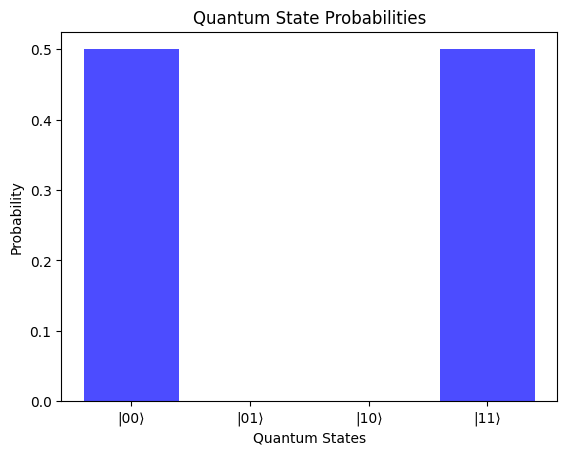


Analyzing molecule 2:
Probabilities for molecule 2: [0.5 0.  0.  0.5]


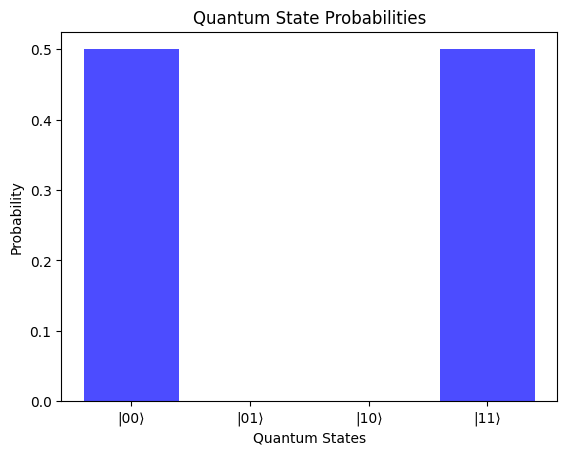


Analyzing molecule 3:
Probabilities for molecule 3: [0.5 0.  0.  0.5]


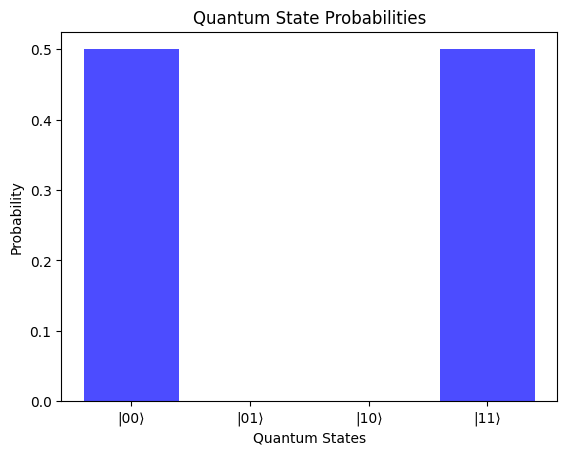

In [7]:
#Step 7: Analyze Molecular Properties
# Analyze multiple molecules
for i, mol in enumerate(rdkit_molecules[:3]):
    print(f"\nAnalyzing molecule {i + 1}:")
    num_qubits, hamiltonian = generate_hamiltonian(mol)
    probabilities = run_quantum_simulation(num_qubits, hamiltonian)
    print(f"Probabilities for molecule {i + 1}: {probabilities}")
    plot_probabilities(probabilities)
